In [ ]:
# This section imports the required data analysis library (Pandas)
# and loads the Instagram post data from an Excel file.
# The Excel file contains two sheets:
# - Sheet 1: Zara Instagram posts
# - Sheet 2: Chanel Instagram posts
# Each sheet is loaded into a separate table (DataFrame) so that
# both brands can be analysed and compared independently.

import pandas as pd

# Load Excel file with two sheets
import os

file_name = "zara_posts_raw(AutoRecovered)-2.xlsx"   # e.g. "zara_chanel_dataset.xlsx"
file_path = os.path.join("/Users/steff/Downloads", file_name)
zara_df = pd.read_excel(file_path, sheet_name=0)
chanel_df = pd.read_excel(file_path, sheet_name=1)

In [ ]:
# This section performs an initial inspection of the datasets.
# The first few rows are displayed to verify that the data
# has been loaded correctly and to understand the structure.
# Missing values are then counted for each column to identify
# any data quality issues that may affect the analysis.

# Preview datasets
print(zara_df.head())
print(chanel_df.head())

# Check for missing values
print(zara_df.isnull().sum())
print(chanel_df.isnull().sum())

  post_id brand                                           post_url  post_date  \
0   ZA001  Zara  https://www.instagram.com/p/C-H2QMwOkkw/?utm_s... 2024-08-01   
1   ZA002  Zara  https://www.instagram.com/reel/C-K8i47Ne_N/?ut... 2024-08-02   
2   ZA003  Zara  https://www.instagram.com/p/C-hXRg-J8Vi/?utm_s... 2024-08-11   
3   ZA004  Zara  https://www.instagram.com/reel/DAaa5VAt4ik/?ut... 2024-09-27   
4   ZA005  Zara  https://www.instagram.com/p/C-mg38ytnXi/?utm_s... 2024-08-13   

                                        caption_text  likes    views  \
0                                AW 24/25 Collection  18800      NaN   
1  ZARA MATES. Meet @jakebongiovi and discover hi...  17100  3200000   
2                                      ZW Collection  28000      NaN   
3  ZARASTREAMING. Watch now!\nStarring @cindycraw...  78300  2600000   
4                           Endless summer wardrobe   31300      NaN   

   comments_count influencer_present content_type           hashtags  \
0       

In [ ]:
# This step cleans the data by removing posts that do not have
# a defined content type (for example: reel, image, carousel).
# Content type is a critical variable for this analysis,
# so rows missing this information are excluded to ensure
# reliable and meaningful comparisons.

zara_df = zara_df.dropna(subset=['content_type'])
chanel_df = chanel_df.dropna(subset=['content_type'])

In [ ]:
# This section calculates how frequently each type of content
# appears in the Instagram posts of Zara and Chanel.
# It helps identify each brand’s content strategy by showing
# whether they rely more on reels, images, or other formats.
# The results are printed for transparent inspection.
 
zara_content_counts = zara_df['content_type'].value_counts()
chanel_content_counts = chanel_df['content_type'].value_counts()

print("Zara Content Types:\n", zara_content_counts)
print("\nChanel Content Types:\n", chanel_content_counts)

Zara Content Types:
 content_type
campaign     78
product      33
Product       7
lifestyle     1
lookbook      1
Name: count, dtype: int64

Chanel Content Types:
 content_type
campaign            110
event presence        8
product campaign      2
Name: count, dtype: int64


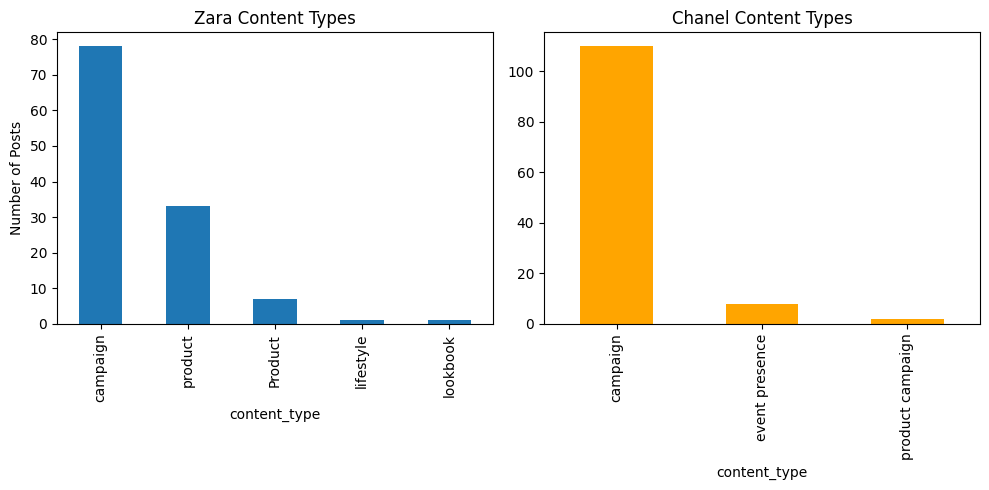

In [ ]:
# This section visualises the distribution of content types
# using bar charts.
# Two charts are shown side-by-side to enable an easy visual
# comparison between Zara and Chanel.
# Visualisation is used here to make patterns and differences
# in content strategy more intuitive and accessible.

import matplotlib.pyplot as plt

# Plot side-by-side bar charts
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
zara_content_counts.plot(kind='bar', title='Zara Content Types')
plt.ylabel("Number of Posts")

plt.subplot(1, 2, 2)
chanel_content_counts.plot(kind='bar', color='orange', title='Chanel Content Types')

plt.tight_layout()
plt.show()

In [ ]:
# This section performs a simple text analysis on post captions
# to identify the most commonly used keywords by each brand.
# Captions are converted to lowercase, cleaned, and filtered
# to retain meaningful words (minimum four letters).
# The most frequent keywords provide insight into the themes
# and messaging priorities of Zara and Chanel.

from collections import Counter
import re

def get_keywords(captions):
    words = " ".join(captions.dropna()).lower()
    words = re.findall(r'\b[a-z]{4,}\b', words)  # only words with 4+ letters
    return Counter(words).most_common(15)

# This final step prints the most frequently used keywords
# for both brands.
# The output supports qualitative interpretation by highlighting
# recurring themes in brand communication.

print("Zara Top Words:", get_keywords(zara_df['caption_text']))
print("Chanel Top Words:", get_keywords(chanel_df['caption_text']))

Zara Top Words: [('zara', 83), ('collection', 57), ('hair', 42), ('creative', 32), ('with', 27), ('director', 27), ('this', 21), ('styling', 20), ('production', 19), ('studio', 17), ('great', 17), ('style', 16), ('designer', 16), ('fabien', 16), ('baron', 16)]
Chanel Top Words: [('chanel', 173), ('with', 118), ('collection', 50), ('discover', 42), ('that', 39), ('allure', 35), ('house', 35), ('link', 31), ('coco', 30), ('gold', 30), ('makeup', 30), ('creation', 29), ('watch', 29), ('inspired', 26), ('rouge', 26)]


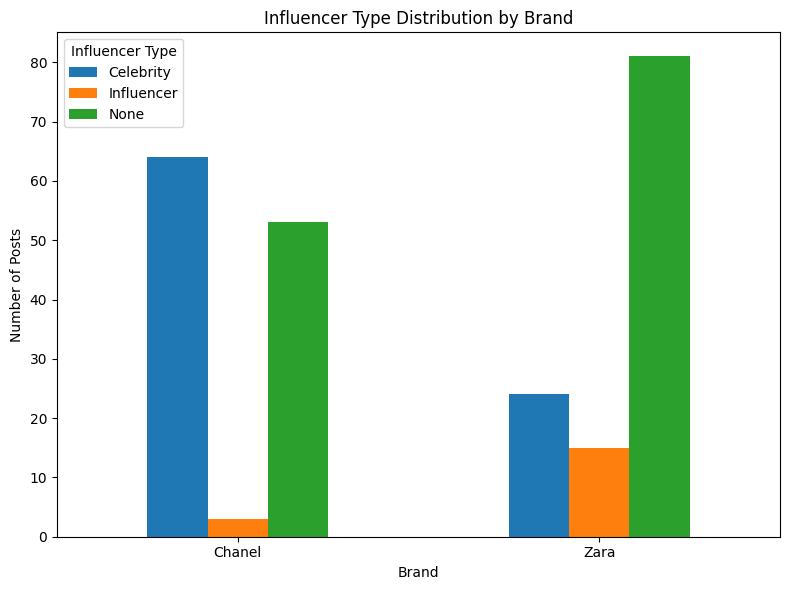

In [ ]:
# This section imports the plotting library used to create charts.
# Visualisation helps present patterns in the data in a way that
# is easy to interpret for non-technical audiences.

import matplotlib.pyplot as plt
# Brand labels are added to each dataset so that posts from
# Zara and Chanel can be clearly distinguished after merging.
# This enables a direct comparison between the two brands
# within a single combined dataset.

# Add brand labels
zara_df['Brand'] = 'Zara'
chanel_df['Brand'] = 'Chanel'

# The two datasets are merged into one unified table.
# Combining the data simplifies comparative analysis and
# allows grouping, counting, and visualisation across brands
# using a consistent structure.

# Combine datasets
df = pd.concat([zara_df, chanel_df], ignore_index=True)

# This step specifies the column that indicates the type of
# influencer associated with each post.
# A validation check is performed to ensure that the expected
# column exists in the dataset before proceeding.

# Rename influencer column if needed (make sure it matches your actual sheet column name)
influencer_col = 'Influencer Type'  # Adjust if needed
if influencer_col not in df.columns:
    print("Check the exact column name for influencer type in your file.")
else:
    # Influencer types are stored as numeric codes in the dataset.
    # These codes are converted into human-readable labels
    # (None, Influencer, Celebrity) to improve interpretability
    # for analysis and reporting.

    # Convert influencer type to readable labels
    influencer_map = {0: 'None', 1: 'Influencer', 2: 'Celebrity'}
    df['Influencer_Label'] = df[influencer_col].map(influencer_map)

    # The data is grouped by brand and influencer type to calculate
    # how many posts fall into each category.
    # This quantifies the extent to which each brand relies on
    # influencers or celebrities in their content strategy.

    # Group and count
    counts = df.groupby(['Brand', 'Influencer_Label']).size().unstack(fill_value=0)

    # A bar chart is created to visually compare influencer usage
    # between Zara and Chanel.
    # This visual representation highlights strategic differences
    # in brand communication and endorsement approaches.

    # Plot
    counts.plot(kind='bar', figsize=(8, 6))
    plt.title('Influencer Type Distribution by Brand')
    plt.ylabel('Number of Posts')
    plt.xlabel('Brand')
    plt.xticks(rotation=0)
    plt.legend(title='Influencer Type')
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import os

file_name = "zara_posts_raw(AutoRecovered)-2.xlsx"   # e.g. "zara_chanel_dataset.xlsx"
file_path = os.path.join("/Users/steff/Downloads", file_name)

comments_df = pd.read_excel(file_path)
comments_df.head()

,post_id,brand,post_url,post_date,caption_text,likes,views,comments_count,influencer_present,content_type,hashtags,Unnamed: 11,Influencer Type,comments
0,ZA001,Zara,https://www.instagram.com/p/C-H2QMwOkkw/?utm_s...,2024-08-01,AW 24/25 Collection,18800,NaN,372,NO,Product,#zarawoman #zara,post,0,Don't order online from Zara! Order canceled a...
1,ZA002,Zara,https://www.instagram.com/reel/C-K8i47Ne_N/?ut...,2024-08-02,ZARA MATES. Meet @jakebongiovi and discover hi...,17100,3200000,95,YES,campaign,#zara @zaraman,Reel,2,My dog’s name is Wolfie too!\n🙌♥️🐾 | Handsome ...
2,ZA003,Zara,https://www.instagram.com/p/C-hXRg-J8Vi/?utm_s...,2024-08-11,ZW Collection,28000,NaN,240,NO,product,#zarawoman #zara,post,0,I am writing from Türkiye. Why are you making ...
3,ZA004,Zara,https://www.instagram.com/reel/DAaa5VAt4ik/?ut...,2024-09-27,ZARASTREAMING. Watch now!\nStarring @cindycraw...,78300,2600000,1119,YES,campaign,#zarastreaming,Reel,2,The last reaction cheek-to-cheek should be blo...
4,ZA005,Zara,https://www.instagram.com/p/C-mg38ytnXi/?utm_s...,2024-08-13,Endless summer wardrobe,31300,NaN,290,NO,product,#zarawoman #zara,post,0,"Worst fashion in the world | Hi, may I know if..."


In [ ]:
import re

# Function to clean text
def clean_text(text):
    if pd.isnull(text):
        return ""
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = text.lower()                  # Lowercase
    return text

# Apply to Zara comments column (assume column name is 'Comments' or similar)
comments_df['clean_comment'] = comments_df['comments'].apply(clean_text)

In [ ]:
from textblob import TextBlob

# Calculate sentiment polarity for each comment
comments_df['sentiment'] = comments_df['clean_comment'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Average sentiment score
avg_sentiment = comments_df['sentiment'].mean()
print("Average Zara Sentiment Score:", avg_sentiment)

Average Zara Sentiment Score: 0.11042434398573665


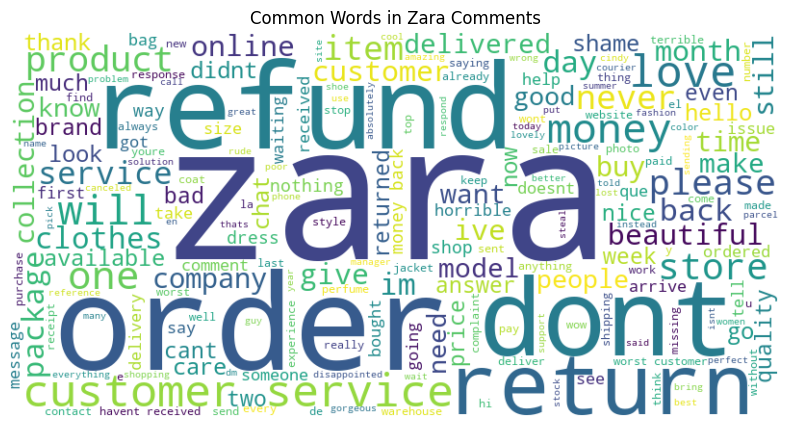

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all cleaned comments
all_words = " ".join(comments_df['clean_comment'].dropna())

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

# Display word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Words in Zara Comments")
plt.show()

In [ ]:
import emoji
from collections import Counter
import pandas as pd

def extract_emojis(s):
    if pd.isna(s):
        return ""
    s = str(s)  # ensures it's iterable
    return ''.join(c for c in s if c in emoji.EMOJI_DATA)

comments_df['emojis'] = comments_df['comments'].apply(extract_emojis)

emoji_counter = Counter("".join(comments_df['emojis']))
print("Most common emojis:", emoji_counter.most_common(10))

Most common emojis: [('❤', 501), ('😍', 499), ('🔥', 325), ('👏', 181), ('🙌', 47), ('😡', 41), ('😂', 38), ('🤍', 37), ('✨', 35), ('👎', 29)]


In [ ]:
# --- RQ2: What type of content drives the most engagement or emotional response in the comments? ---

# Sentiment Analysis
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

zara_df['sentiment_score'] = zara_df['comments'].apply(get_sentiment)

zara_df['sentiment_label'] = zara_df['sentiment_score'].apply(
    lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))

# Count the sentiment labels
print("Sentiment distribution:")
print(zara_df['sentiment_label'].value_counts())

Sentiment distribution:
sentiment_label
positive    84
negative    35
neutral      1
Name: count, dtype: int64


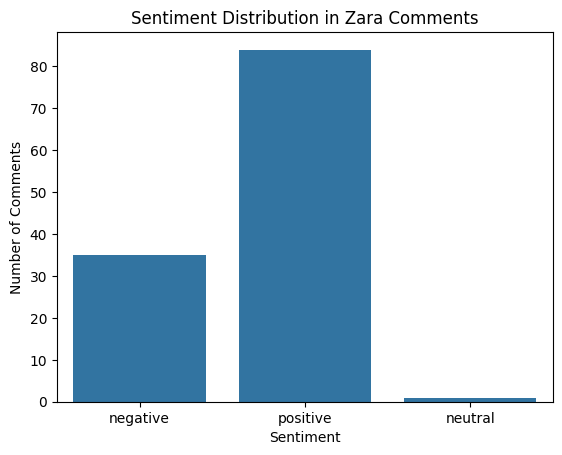

In [ ]:
# Visualize Sentiment Distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment_label', data=zara_df)
plt.title('Sentiment Distribution in Zara Comments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Comments')
plt.show()

In [ ]:
# Optional: Topic Modeling to extract common themes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Vectorize cleaned comments
vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=2)
doc_term_matrix = vectorizer.fit_transform(zara_df['comments'].dropna())

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(doc_term_matrix)

# Print top words per topic
for idx, topic in enumerate(lda.components_):
    print(f"Topic #{idx + 1}:")
    print([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])

Topic #1:
['quality', 'make', 'know', 'available', 'customer', 'refund', 'like', 'don', 'collection', 'love']
Topic #2:
['love', 'received', 'store', 'return', 'don', 'refund', 'money', 'customer', 'service', 'order']
Topic #3:
['just', 'beautiful', 'like', 'que', 'refund', 'people', 'customer', 'clothes', 'love', 'service']


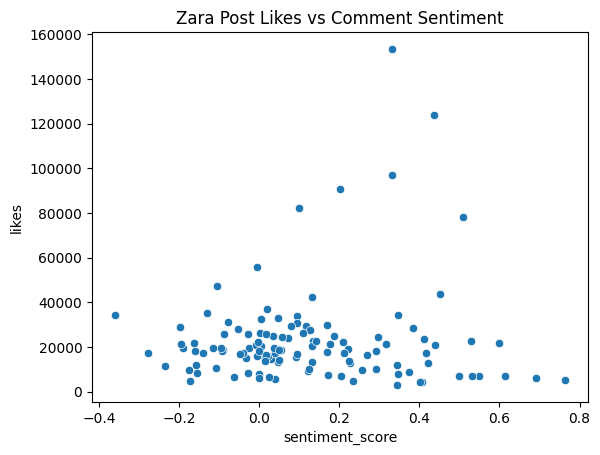

Average likes per sentiment category:
sentiment_label
negative    20582.457143
neutral      6302.000000
positive    24331.059524
Name: likes, dtype: float64


In [ ]:
# Correlate sentiment with likes (if 'likes' column is present)
if 'likes' in zara_df.columns:
    sns.scatterplot(data=zara_df, x='sentiment_score', y='likes')
    plt.title("Zara Post Likes vs Comment Sentiment")
    plt.show()

    print("Average likes per sentiment category:")
    print(zara_df.groupby('sentiment_label')['likes'].mean())

In [ ]:
# -- LDA Topic Modeling on Zara Comments --
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Preprocess comments
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
zara_comments_clean = zara_df['comments'].dropna().astype(str).str.lower()

vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=stop_words)
dtm = vectorizer.fit_transform(zara_comments_clean)

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(dtm)

# Show top words per topic
def display_topics(model, feature_names, no_top_words):
    for idx, topic in enumerate(model.components_):
        print(f"Topic {idx + 1}:")
        print(" | ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

display_topics(lda, vectorizer.get_feature_names_out(), 10)

Topic 1:
zara | order | service | customer | refund | money | one | back | return | still
Topic 2:
zara | love | service | customer | like | order | money | return | refund | never
Topic 3:
zara | money | refund | order | service | customer | back | never | nice | please


[nltk_data] Downloading package stopwords to /Users/steff/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation

# 1) Pick the text column you want
# Change 'clean_comment' to your actual column name if needed
texts = comments_df["clean_comment"].fillna("").astype(str)

# 2) Vectorize (document-term matrix)
vectorizer = CountVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS),
    max_df=0.95,
    min_df=2
)
dtm = vectorizer.fit_transform(texts)

# 3) Fit LDA (choose number of topics)
n_topics = 8
lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42,
    learning_method="batch"
)
lda.fit(dtm)

# 4) Visualize with pyLDAvis
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.108254  0.036846       1        1  46.197394
1     -0.057814  0.010132       2        1  16.858305
4      0.021354 -0.140442       3        1  11.332108
0     -0.091112  0.091162       4        1   7.632055
7      0.207853  0.073171       5        1   6.068993
6      0.006858 -0.016802       6        1   5.281879
5     -0.045030 -0.039237       7        1   5.108633
2      0.066143 -0.014830       8        1   1.520635, topic_info=          Term        Freq       Total Category  logprob  loglift
1291      zara  394.000000  394.000000  Default  30.0000  30.0000
671       love   94.000000   94.000000  Default  29.0000  29.0000
1001   service  155.000000  155.000000  Default  28.0000  28.0000
348       dont  112.000000  112.000000  Default  27.0000  27.0000
284   customer  143.000000  143.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1087     store    1.063899   58.381285   Topic8  -4.9595   0.1810
644       like    1.063887   71.076697   Topic8  -4.9595  -0.0158
671       love    1.063886   94.899821   Topic8  -4.9595  -0.3049
661       look    0.725055   16.416936   Topic8  -5.3429   1.0662
613       know    0.699395   31.953721   Topic8  -5.3789   0.3642

[543 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
10        3  0.881595     1st
11        2  0.259110      20
11        3  0.518220      20
11        6  0.129555      20
14        1  0.548924      24
...     ...       ...     ...
1291      6  0.055815    zara
1291      7  0.053278    zara
1291      8  0.007611    zara
1298      1  0.291851  zipper
1298      4  0.583703  zipper

[1073 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 5, 1, 8, 7, 6, 3])

In [ ]:
import pyLDAvis
import pyLDAvis.lda_model

lda_vis = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3     -0.108254  0.036846       1        1  46.197394
1     -0.057814  0.010132       2        1  16.858305
4      0.021354 -0.140442       3        1  11.332108
0     -0.091112  0.091162       4        1   7.632055
7      0.207853  0.073171       5        1   6.068993
6      0.006858 -0.016802       6        1   5.281879
5     -0.045030 -0.039237       7        1   5.108633
2      0.066143 -0.014830       8        1   1.520635, topic_info=          Term        Freq       Total Category  logprob  loglift
1291      zara  394.000000  394.000000  Default  30.0000  30.0000
671       love   94.000000   94.000000  Default  29.0000  29.0000
1001   service  155.000000  155.000000  Default  28.0000  28.0000
348       dont  112.000000  112.000000  Default  27.0000  27.0000
284   customer  143.000000  143.000000  Default  26.0000  26.0000
...        ...         ...         ...      ...      ...      ...
1087     store    1.063899   58.381285   Topic8  -4.9595   0.1810
644       like    1.063887   71.076697   Topic8  -4.9595  -0.0158
671       love    1.063886   94.899821   Topic8  -4.9595  -0.3049
661       look    0.725055   16.416936   Topic8  -5.3429   1.0662
613       know    0.699395   31.953721   Topic8  -5.3789   0.3642

[543 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
10        3  0.881595     1st
11        2  0.259110      20
11        3  0.518220      20
11        6  0.129555      20
14        1  0.548924      24
...     ...       ...     ...
1291      6  0.055815    zara
1291      7  0.053278    zara
1291      8  0.007611    zara
1298      1  0.291851  zipper
1298      4  0.583703  zipper

[1073 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 5, 1, 8, 7, 6, 3])

In [ ]:
pyLDAvis.save_html(lda_vis, "lda_vis.html")

In [ ]:
zara_df.columns

Index(['post_id', 'brand', 'post_url', 'post_date', 'caption_text', 'likes',
       'views', 'comments_count', 'influencer_present', 'content_type',
       'hashtags', 'Unnamed: 11', 'Influencer Type', 'comments', 'Brand',
       'sentiment_score', 'sentiment_label'],
      dtype='object')

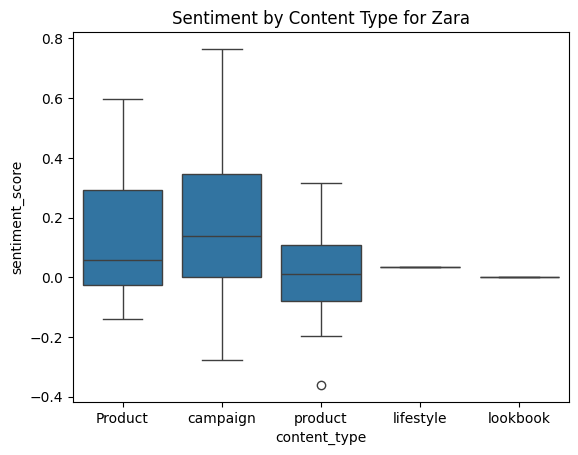

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=zara_df, x="content_type", y="sentiment_score")
plt.title("Sentiment by Content Type for Zara")
plt.show()